In [23]:
#using Pkg
#ENV["GRDIR"]=""
#Pkg.build("GR")

   Building GR → `~/.julia/packages/GR/oiZD3/deps/build.log`


In [1]:
using Plots
using Turing
using StatsPlots

In [2]:
dx_measured = Float64[25.94, 38.84, 52.81, 45.54, 17.24]
t_measured  = Float64[ 3.91,  4.57,  5.43,  4.85,  3.15]

5-element Array{Float64,1}:
 3.91
 4.57
 5.43
 4.85
 3.15

In [3]:
@model gravity_uniform(t_final, x_final, theta) = begin
    g ~ Uniform(0, 10)
    mu = g .* (t_final .* t_final ./ 2)
    N = length(t_final)
    for n in 1:N
        x_final[n] ~ Normal(mu[n], 10)
    end
end

(::DynamicPPL.ModelGen{(:t_final, :x_final, :theta),var"###gravity_uniform#288",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [4]:
ITERS = 10000
EPS = 0.05
TAU = 10

10

In [5]:
theta = 45
chainuniform = sample(gravity_uniform(t_measured, dx_measured, theta),
                      HMC(EPS, TAU),
                      ITERS,
                      progress=false)

Object of type Chains, with data of type 10000×10×1 Array{Real,3}

Iterations        = 1:10000
Thinning interval = 1
Chains            = 1
Samples per chain = 10000
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size
parameters        = g

2-element Array{ChainDataFrame,1}

Summary Statistics
. Omitted printing of 1 columns
│ Row │ parameters │ mean    │ std      │ naive_se   │ mcse       │ ess     │
│     │ Symbol     │ Float64 │ Float64  │ Float64    │ Float64    │ Any     │
├─────┼────────────┼─────────┼──────────┼────────────┼────────────┼─────────┤
│ 1   │ g          │ 3.65517 │ 0.414684 │ 0.00414684 │ 0.00115751 │ 12627.6 │

Quantiles

│ Row │ parameters │ 2.5%    │ 25.0%   │ 50.0%   │ 75.0%   │ 97.5%   │
│     │ Symbol     │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├─────┼────────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ 1   │ g          │ 2.85354 │ 3.37704 │ 3.6

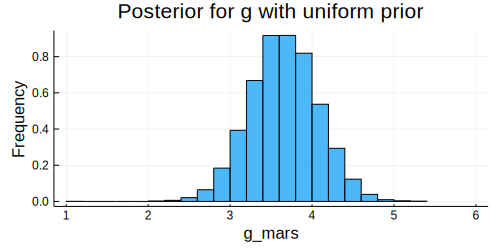

In [6]:
histogram(chainuniform[:g], xlim=[1, 6], legend=false, normalized=true)
xlabel!("g_mars")
title!("Posterior for g with uniform prior")

In [7]:
@model gravity_normal(t_final, x_final, theta) = begin
    N = length(t_final) 
    g ~ Normal(6, 2)
    mu = g .* (t_final.^2 ./ 2)
    for n in 1:N
        x_final[n] ~ Normal(mu[n], 3)
    end
end

(::DynamicPPL.ModelGen{(:t_final, :x_final, :theta),var"###gravity_normal#322",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [8]:
chainnormal = sample(gravity_normal(t_measured, dx_measured, theta),
                     HMC(EPS, TAU),
                     ITERS,
                     progress=false)

Object of type Chains, with data of type 10000×10×1 Array{Real,3}

Iterations        = 1:10000
Thinning interval = 1
Chains            = 1
Samples per chain = 10000
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size
parameters        = g

2-element Array{ChainDataFrame,1}

Summary Statistics
. Omitted printing of 1 columns
│ Row │ parameters │ mean    │ std     │ naive_se  │ mcse        │ ess     │
│     │ Symbol     │ Float64 │ Float64 │ Float64   │ Float64     │ Any     │
├─────┼────────────┼─────────┼─────────┼───────────┼─────────────┼─────────┤
│ 1   │ g          │ 3.66728 │ 0.12788 │ 0.0012788 │ 0.000528246 │ 17433.6 │

Quantiles

│ Row │ parameters │ 2.5%    │ 25.0%   │ 50.0%   │ 75.0%   │ 97.5%   │
│     │ Symbol     │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├─────┼────────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ 1   │ g          │ 3.4164  │ 3.58059 │ 3.66636

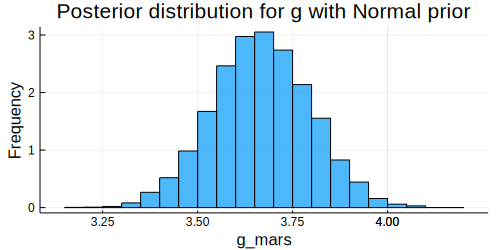

In [9]:
histogram(chainnormal[:g], legend=false, normalized=true)
xlabel!("g_mars")
title!("Posterior distribution for g with Normal prior")

In [11]:
@model gravity_lognormal(t_final, x_final) = begin
    N = length(t_final)
    g ~ LogNormal(0.5, 0.5)
    mu = g .* (t_final.^2 ./ 2)
    for n in 1:N
        x_final[n] ~ Normal(mu[n], 3)
    end
end

(::DynamicPPL.ModelGen{(:t_final, :x_final),var"###gravity_lognormal#354",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [12]:
chainlognormal = sample(gravity_lognormal(t_measured, dx_measured),
                        HMC(EPS, TAU),
                        ITERS,
                        progress=false)

Object of type Chains, with data of type 10000×10×1 Array{Real,3}

Iterations        = 1:10000
Thinning interval = 1
Chains            = 1
Samples per chain = 10000
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size
parameters        = g

2-element Array{ChainDataFrame,1}

Summary Statistics
. Omitted printing of 1 columns
│ Row │ parameters │ mean    │ std      │ naive_se   │ mcse       │ ess     │
│     │ Symbol     │ Float64 │ Float64  │ Float64    │ Float64    │ Any     │
├─────┼────────────┼─────────┼──────────┼────────────┼────────────┼─────────┤
│ 1   │ g          │ 3.63823 │ 0.129703 │ 0.00129703 │ 0.00139256 │ 12197.8 │

Quantiles

│ Row │ parameters │ 2.5%    │ 25.0%   │ 50.0%   │ 75.0%   │ 97.5%   │
│     │ Symbol     │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├─────┼────────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ 1   │ g          │ 3.38553 │ 3.55801 │ 3.6

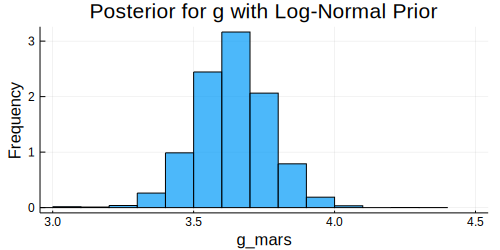

In [13]:
histogram(chainlognormal[:g], xlim=[3, 4.5], legend=false, normalize=true)
xlabel!("g_mars")
title!("Posterior for g with Log-Normal Prior")

In [14]:
@model gravity_angle_uniform(t_final, x_final) = begin
    err = 15
    angle ~ Uniform(45 - err/2, 45 + err/2)
    g ~ LogNormal(log(4), 0.3)
    mu = g .* (t_final.^2 ./ (2tan.(deg2rad(angle))))
    N = length(t_final)
    for n in 1:N
        x_final[n] ~ Normal(mu[n], 10)
    end
end

(::DynamicPPL.ModelGen{(:t_final, :x_final),var"###gravity_angle_uniform#390",NamedTuple{(),Tuple{}}}) (generic function with 1 method)

In [15]:
chain_uniform_angle = sample(
    gravity_angle_uniform(t_measured, dx_measured),
    HMC(EPS, TAU), 
    ITERS,
    progress=false)

Object of type Chains, with data of type 10000×11×1 Array{Real,3}

Iterations        = 1:10000
Thinning interval = 1
Chains            = 1
Samples per chain = 10000
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size
parameters        = angle, g

2-element Array{ChainDataFrame,1}

Summary Statistics
. Omitted printing of 1 columns
│ Row │ parameters │ mean    │ std      │ naive_se   │ mcse      │ ess     │
│     │ Symbol     │ Float64 │ Float64  │ Float64    │ Float64   │ Any     │
├─────┼────────────┼─────────┼──────────┼────────────┼───────────┼─────────┤
│ 1   │ angle      │ 45.7159 │ 4.08071  │ 0.0408071  │ 0.220254  │ 290.845 │
│ 2   │ g          │ 3.7747  │ 0.620779 │ 0.00620779 │ 0.0248761 │ 463.5   │

Quantiles

│ Row │ parameters │ 2.5%    │ 25.0%   │ 50.0%   │ 75.0%   │ 97.5%   │
│     │ Symbol     │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├─────┼────────────┼─────────┼─────

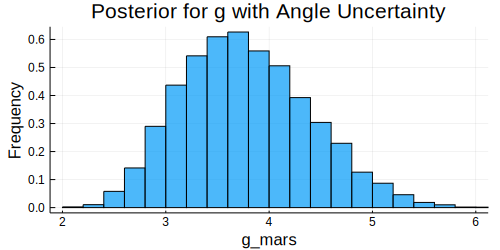

In [17]:
histogram(
    chain_uniform_angle[:g], xlim=[2, 6], legend=false, normalize=true)
xlabel!("g_mars")
title!("Posterior for g with Angle Uncertainty")

In [26]:
v = 11 .* sqrt.(chain_uniform_angle[:g] ./ (9.8 * 2)) 

LoadError: MethodError: no method matching iterate(::Chains{Real,Missing,NamedTuple{(:parameters,),Tuple{Array{String,1}}},NamedTuple{(:range, :model, :spl, :vi, :hashedsummary),Tuple{Random._GLOBAL_RNG,DynamicPPL.Model{var"##inner_function#370#8",NamedTuple{(:t_final, :x_final),Tuple{Array{Float64,1},Array{Float64,1}}},DynamicPPL.ModelGen{(:t_final, :x_final),var"###gravity_angle_uniform#390",NamedTuple{(),Tuple{}}},Val{()}},DynamicPPL.Sampler{HMC{Turing.Core.ForwardDiffAD{40},(),AdvancedHMC.UnitEuclideanMetric},Turing.Inference.HMCState{DynamicPPL.VarInfo{NamedTuple{(:angle, :g),Tuple{DynamicPPL.Metadata{Dict{DynamicPPL.VarName{:angle},Int64},Array{Uniform{Float64},1},Array{DynamicPPL.VarName{:angle},1},Array{Float64,1},Array{Set{DynamicPPL.Selector},1}},DynamicPPL.Metadata{Dict{DynamicPPL.VarName{:g},Int64},Array{LogNormal{Float64},1},Array{DynamicPPL.VarName{:g},1},Array{Float64,1},Array{Set{DynamicPPL.Selector},1}}}},Float64},AdvancedHMC.StaticTrajectory{AdvancedHMC.EndPointTS,Adv

In [ ]:
histogram(v, legend=false, normalized=true)
title!("Escape velocity for Mars")
xlabel!("Velocity (km/s)")
ylabel!("Prob")